# Image Classification with CIFAR-10 Dataset and Scikit-Learn

In this notebook, we will explore the basics of image classification using the CIFAR-10 dataset and build a simple image classifier using Scikit-Learn. We will perform the following steps:
1. Load and preprocess the CIFAR-10 dataset.
2. Extract features from the images.
3. Train a machine learning model on the extracted features.
4. Evaluate the model's performance.

## Step 1: Installing and Importing Libraries

### Installing Libraries

Before we start, we need to ensure that we have all the necessary libraries installed. We can use `!pip install` to install any missing libraries directly from the Jupyter Notebook. This command is useful for installing Python packages from the Python Package Index (PyPI).

### Why Install Libraries?

Libraries provide pre-written code that we can use to perform various tasks without having to write everything from scratch. Installing libraries ensures we have access to the necessary functions and tools needed for our project.

Here are the libraries we need for this notebook:
- **numpy:** For numerical operations.
- **matplotlib:** For plotting and visualizing images.
- **tensorflow:** For loading the CIFAR-10 dataset.
- **scikit-learn (sklearn):** For machine learning models and evaluation metrics.

### Installing Libraries Individually vs. All at Once


You can install each library separately by writing a `!pip install` command for each library. This looks like:
```python
!pip install numpy
!pip install matplotlib
!pip install tensorflow
!pip install scikit-learn


Alternatively, you can install all the libraries together in a single !pip install command by separating the library names with a space

!pip install numpy matplotlib tensorflow scikit-learn

## Differences and Considerations
- **Convenience**: Installing all libraries at once is more convenient and requires fewer lines of code. It can save time when writing and running the notebook.
- **Execution Time**: Running a single !pip install command can be faster than running multiple commands, as it reduces the overhead of initiating separate installation processes for each library.
- **Dependency Management**: Installing libraries together can help Pip resolve dependencies more efficiently, potentially avoiding conflicts that might arise when installing libraries separately.
- **Debugging**: Installing libraries individually can make it easier to identify which specific library caused an issue if an installation error occurs. However, this is generally only a concern if you encounter frequent installation problems.

For this notebook, we will install all necessary libraries together for convenience.

In [ ]:
!pip install numpy matplotlib tensorflow scikit-learn


### Importing Libraries

After installing the libraries, we need to import them into our notebook. Importing libraries allows us to use their functionalities in our code. Each library is imported using an alias (short name) to make the code cleaner and more readable.

Let's import the required libraries:


In [ ]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score


## Step 2: Loading and Preprocessing the CIFAR-10 Dataset

The CIFAR-10 dataset is readily available in the `keras` library. We will load the dataset and preprocess it by converting the images to grayscale and flattening them.


In [ ]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# To minimize computational demands lets work with three classes of your choice

# CIFAR-10 classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


# Choose a subset of classes
chosen_classes = ['cat', 'dog', 'ship']
class_indices = [class_names.index(cls) for cls in chosen_classes]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4995s 29us/step


In [ ]:
# Filter data for the chosen classes
mask_train = np.isin(y_train, class_indices)
mask_test = np.isin(y_test, class_indices)
X_train_subset = X_train[mask_train.flatten()]
y_train_subset = y_train[mask_train]
X_test_subset = X_test[mask_test.flatten()]
y_test_subset = y_test[mask_test]


In [ ]:
# Convert images to grayscale
X_train_gray = np.dot(X_train_subset[...,:3], [0.2989, 0.5870, 0.1140])
X_test_gray = np.dot(X_test_subset[...,:3], [0.2989, 0.5870, 0.1140])

# Normalize the images
X_train_normalized = X_train_gray / 255.0
X_test_normalized = X_test_gray / 255.0

# Flatten the images
X_train_flat = X_train_normalized.reshape(X_train_normalized.shape[0], -1)
X_test_flat = X_test_normalized.reshape(X_test_normalized.shape[0], -1)




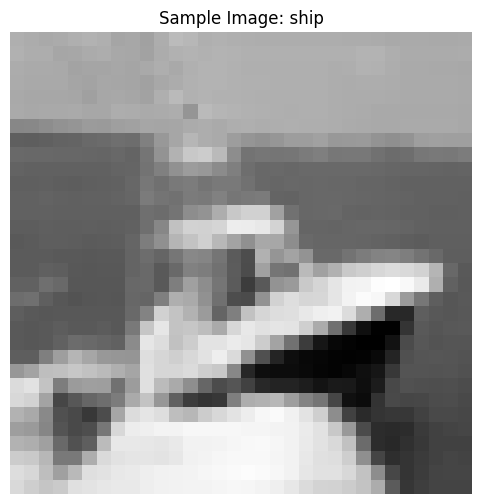

Training set size: (15000, 1024)
Testing set size: (3000, 1024)


In [ ]:
# Display a sample image
plt.figure(figsize=(6, 6))
plt.imshow(X_train_gray[0], cmap='gray')
plt.title(f'Sample Image: {chosen_classes[np.where(class_indices == y_train_subset[0])[0][0]]}')
plt.axis('off')
plt.show()

print("Training set size:", X_train_flat.shape)
print("Testing set size:", X_test_flat.shape)

## Step 3: Training a Machine Learning Model

### What is SVM (Support Vector Machine)?

Support Vector Machine (SVM) is a supervised machine learning algorithm that can be used for both classification and regression tasks. However, it is mostly used for classification problems. The objective of the SVM algorithm is to find a hyperplane in an N-dimensional space (N is the number of features) that distinctly classifies the data points.

### Key Concepts:

- **Hyperplane:** A decision boundary that separates different classes in the feature space. In 2D, it's a line; in 3D, it's a plane.
- **Support Vectors:** Data points that are closest to the hyperplane and influence its position and orientation. These points help in maximizing the margin of the classifier.
- **Margin:** The distance between the hyperplane and the closest data points from either class. SVM aims to maximize this margin.

### Why Use SVM?

- **Effective in high-dimensional spaces:** SVM is very effective when the number of features is large.
- **Memory efficient:** It uses a subset of training points (support vectors) in the decision function, making it memory efficient.
- **Versatile:** Different kernel functions can be specified for the decision function. Common kernels include linear, polynomial, and radial basis function (RBF).

### What does `SVC(kernel='linear')` mean?

`SVC` stands for Support Vector Classification, which is a class in the Scikit-Learn library used to implement the SVM algorithm for classification tasks. The `kernel` parameter in the `SVC` class specifies the type of hyperplane used to separate the data.

#### Kernel Types:

- **Linear Kernel:** The data is linearly separable (i.e., a straight line or hyperplane can separate the data). This is the simplest kernel.
  - When we use `SVC(kernel='linear')`, it means we are using a linear kernel for our SVM. This kernel is appropriate when the data can be separated by a straight line (or hyperplane in higher dimensions).
- **Polynomial Kernel:** The data is not linearly separable, but a polynomial function of the input features can separate the data.
- **Radial Basis Function (RBF) Kernel:** The data is not linearly separable, but mapping the data into a higher-dimensional space using a Gaussian (RBF) function can separate the data.

### Training the SVM Model

We will use a Support Vector Machine (SVM) classifier from Scikit-Learn to train our model on the extracted features.


In [ ]:
# Train an SVM classifier
model = SVC(kernel='linear')
model.fit(X_train_flat, y_train_subset.ravel())

# Predict on the test set
y_pred = model.predict(X_test_flat)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test_subset, y_pred))
print("Classification Report:\n", classification_report(y_test_subset, y_pred, target_names=chosen_classes))




Accuracy: 0.547
Classification Report:
               precision    recall  f1-score   support

         cat       0.48      0.48      0.48      1000
         dog       0.49      0.48      0.49      1000
        ship       0.66      0.68      0.67      1000

    accuracy                           0.55      3000
   macro avg       0.54      0.55      0.55      3000
weighted avg       0.54      0.55      0.55      3000



In [ ]:
# Train an SVM classifier
model = SVC(kernel='rbf', C=10, gamma='scale')
model.fit(X_train_flat, y_train_subset.ravel())

# Predict on the test set
y_pred = model.predict(X_test_flat)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test_subset, y_pred))
print("Classification Report:\n", classification_report(y_test_subset, y_pred, target_names=chosen_classes))

Accuracy: 0.684
Classification Report:
               precision    recall  f1-score   support

         cat       0.58      0.61      0.59      1000
         dog       0.62      0.61      0.62      1000
        ship       0.86      0.83      0.84      1000

    accuracy                           0.68      3000
   macro avg       0.69      0.68      0.69      3000
weighted avg       0.69      0.68      0.69      3000



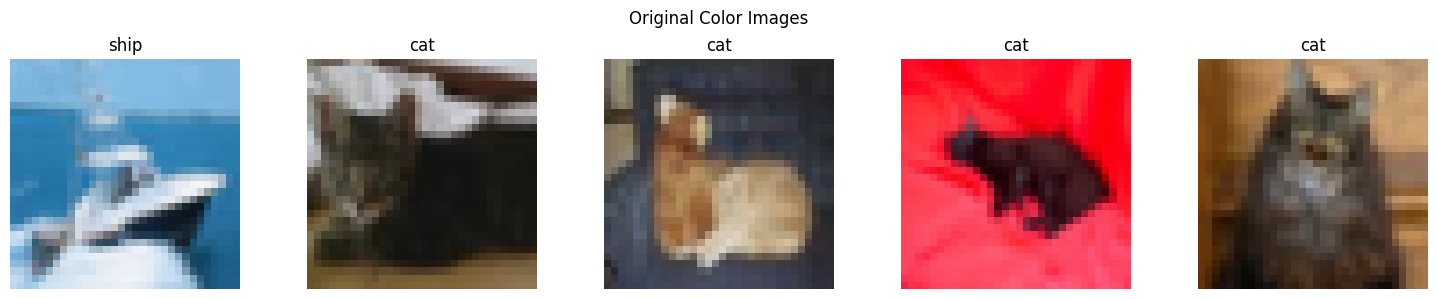

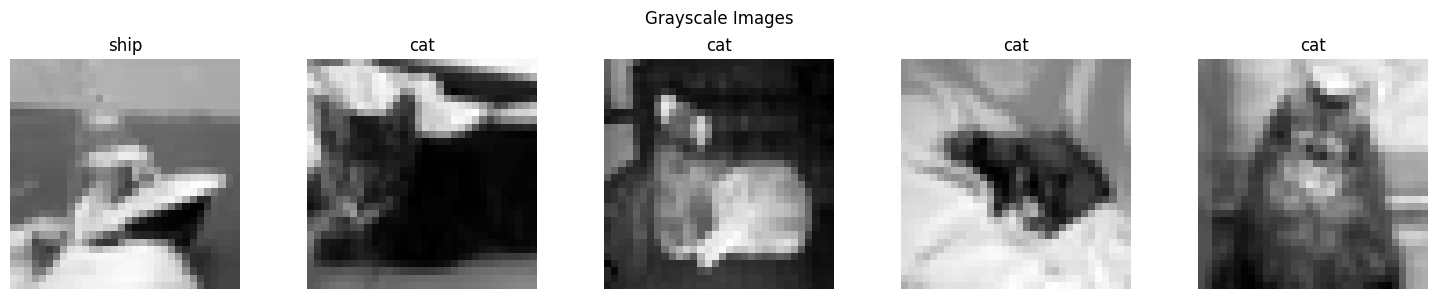

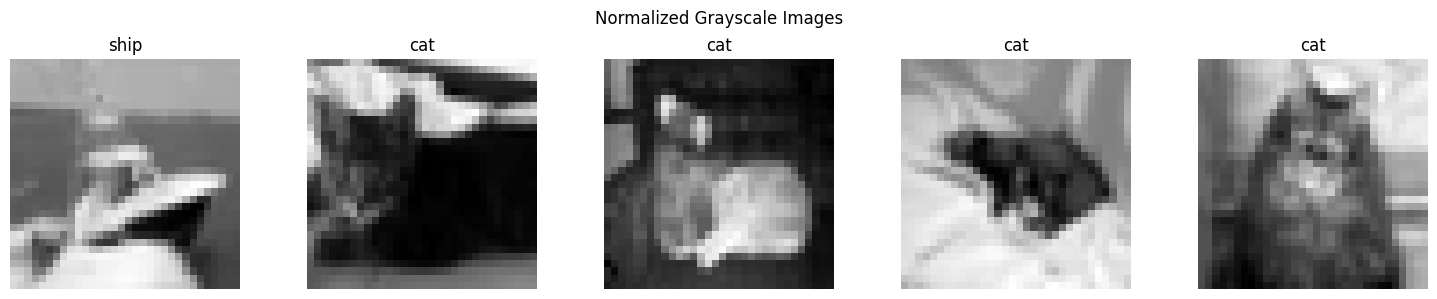

In [ ]:
# Lets see some images of the  datasset in the different stages
# Function to display images
def display_images(images, titles, main_title, cmap=None):
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(main_title)
    for i, ax in enumerate(axes):
        if cmap:
            ax.imshow(images[i], cmap=cmap)
        else:
            ax.imshow(images[i])
        ax.set_title(titles[i])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Display original color images
display_images(X_train_subset[:5],
               [chosen_classes[np.where(class_indices == y)[0][0]] for y in y_train_subset[:5]],
               'Original Color Images')

# Display grayscale images
display_images(X_train_gray[:5],
               [chosen_classes[np.where(class_indices == y)[0][0]] for y in y_train_subset[:5]],
               'Grayscale Images', cmap='gray')

# Display normalized images
display_images(X_train_normalized[:5],
               [chosen_classes[np.where(class_indices == y)[0][0]] for y in y_train_subset[:5]],
               'Normalized Grayscale Images', cmap='gray')

## Prediction Visualization

This visualization shows some test images with their true labels and the labels predicted by the SVM model. It helps us understand the model’s performance visually, not only through accuracy numbers. If the true label and predicted label are the same, the model classified the image correctly. If they are different, the model made a mistake. This is useful because it shows which classes the model may confuse, such as cat and dog.

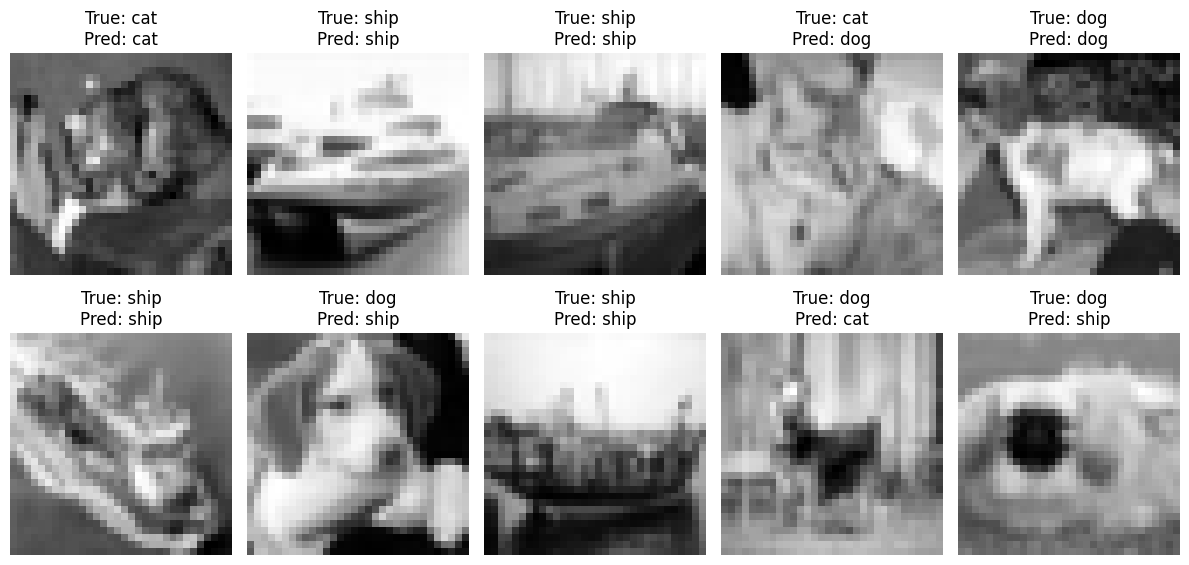

In [ ]:
# Visualize test images with true and predicted labels
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_gray[i], cmap='gray')

    true_label = class_names[int(y_test_subset[i])]
    predicted_label = class_names[int(y_pred[i])]

    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Step 4: Conclusion

In this notebook, we:
1. Loaded and preprocessed the CIFAR-10 dataset.
2. Converted the images to grayscale and flattened them to use as features.
3. Trained an SVM classifier on the extracted features.
4. Evaluated the model's performance.

### Summary of SVM

Support Vector Machines (SVM) are a powerful tool for classification tasks. They work by finding the optimal hyperplane that maximizes the margin between different classes. The key points include:
- **Hyperplane:** The decision boundary.
- **Support Vectors:** Critical data points that define the hyperplane.
- **Margin:** The gap between the hyperplane and the nearest data points from any class.

SVMs are effective in high-dimensional spaces and are versatile due to the use of different kernel functions. However, they can be computationally intensive for large datasets and less effective for overlapping classes.

This exercise provided a basic introduction to image classification using classical machine learning techniques. Next  few modules will explore advanced applications, using deep learning models like Convolutional Neural Networks (CNNs) using libraries such as TensorFlow or PyTorch.


# L03b Image Classification Reflective Journal
Support vector machines (SVM) is a supervised learning method meaning that it learns from labeled data. It is  used for classification, regression, and outlier detection. We specifically use classification for this lab to classify images. In case of images, SVM can be used to classify the images, detect objects in the image, and face detection. “SVCs aim to find a hyperplane that effectively separates the classes”(Scikit-learn developers, 2026). A hyperplane is a linear or curved line that is drawn for classifying different groups. SVM can use different kernels, such as linear, polynomial, and RBF kernels. A kernel helps the model handle data that may not be separated easily with a simple straight boundary. Kernels are important in SVM because they allow the model to classify data with more complex patterns. A linear kernel creates a simpler boundary, while RBF or polynomial kernels can model more complex relationships between features (sickit-learn).
## Preprocessing
For this lab, the CIFAR-10 dataset was used, which has images of 10 different classes to get the image data and labels. . For simplicity and to save time we only used three classes of this dataset: cats, dogs, and ships. We also have to remove the rest of the classes from the dataset, so the model only sees the specified classes. The next step is converting colored images to grayscale images. Reducing the image from 3 color channels to 1 brightness channel decreases the storage and speeds up the process. Normalization is another step for helping models to work better. It means changing pixel values by dividing them by 255.0, so they can fall between 0 and 1, a range of numbers that models understand very well.  Flattening is one of the most important steps for SVM because SVM models are not designed to work directly with image grids. Consequently we need to change each grid of grayscale images into a one-dimensional vector. For this lab each  32 * 32 images need to be converted to 1024 features, so the model can read and understand the image. SVM needs data in a table format, where each image is one row of features. After doing all the preprocessing and setting images, we need to divide the data into training and testing sets. The model was trained on training data, using the sample images and labeled data. Then , we evaluate the model using testing data. Different tools and metrics can be used to measure and evaluate the results.
## Model Training
SVC stands for Support Vector Classification, a class in the Scikit-Learn library that is used to perform SVM tasks. For this lab, a linear kernel was used because it is faster, simpler, and easier to understand for beginners like us. The linear kernel is the method that finds the boundary between classes, when the relationship between features and classes is approximately linear. The model was trained on training data, to be prepared for the test. Then, we evaluate the model using the testing set of the data.
## Output Evaluation
The output of the lab was evaluated using accuracy and the classification report.  The result showed 0.547 accuracy. Diving deeper, the model was better at predicting ships with 0.6 F1 score, while the cats and dogs category had around  0.4 F1 score. The reason can be the similarity of cats and dogs in some cases. The model can easily make a mistake predicting a dog as a cat, while ships have completely different shapes with different environments. To get a better score I tried the RBF kernel, and surprisingly it worked better with 0.684 accuracy. The F1 score for each one: Cats 0.59, dogs 0.62, and ships 0.84 indicates better prediction for all classes,  especially ships. The RBF kernel can capture more complex patterns resulting in better accuracy. The model is still not perfect for classifying all the categories, however it can be a base to work on.
The challenging part of the lab for me was finding a model with better accuracy. An accuracy of 55% means from every 100 images the model can only predict 55 of them correctly. I tried using a different kernel to increase this amount. RBF kernel increased the correct predictions around 68, which is not perfect but good enough for this lab.
Overall, this lab was a good opportunity to learn about SVM applications, methods, and usage. I learned how the preprocessing steps are important and can affect the model performance. For example, if we did not flatten the images, the SVM model could not process the images. Furthermore, the chosen model can make a huge difference like linear and RBF. The preprocessing and the chosen model can have a strong effect on the performance of the project.

## References:
Scikit-learn developers. (2026). Plot classification boundaries with different SVM kernels. scikit-learn.
Scikit-learn developers. (2026). Support Vector Machines. scikit-learn.

Elham Timory

ITAI 1378

06/17/2026